In [1]:
from src.backend import TorchBackend, Backend
from src.geometry import Rectangle, Bitmap, Lattice, VectorObject, Ellipse
from src.layer import Layer
from src.material import Material
from src.tvf import TVF
from src.source import Source
from src.sim import LayerSolver
from src.config import LayerConfig

import torch
import matplotlib.pyplot as plt
from typing import Any

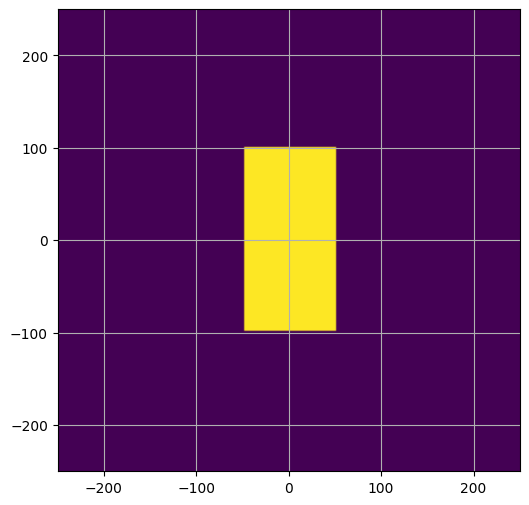

In [9]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)


Lx = 500
Ly = 500
Nx = 201
Ny = 201
M = 13
N = 13


period = (Lx, Ly)
grid = (Nx, Ny)
lattice = Lattice(period=period, grid=grid)

center = (0, 0)
size = (100, 200)
angle = 0.0*torch.pi/180

epsilon = [15.0+1j, 2.0, 3.0]
epsilon_bg = [1, 2.2, 2.5 + 0j]

mat = Material(backend, epsilon=epsilon)
mat_bg = Material(backend, epsilon=epsilon_bg)

shape = Rectangle(backend, lattice, center=center, size=size, material=mat, angle=angle, soft_mask=False)
layer = Layer(shape, thickness=500, material_bg=mat_bg)

wavelength = [400, 600, 700.0]
theta = [0.0, 10.0]
phi = [0.0, 2.0]
source = Source(backend, wavelength=wavelength, theta=theta, phi=phi)
n_inc = 1.0

cfg = LayerConfig(M = M, N = N, 
                  closed_form=True,
                  circ_truncation=True, 
                  factorization='Pol', tvf_optimizer='LBFGS',
                  tvf_alpha=1.0, tvf_beta=1e-6, tvf_gamma=0, tvf_steps=1,
                  modes_solver='eig')

solver = LayerSolver(layer, source, cfg, n_inc)

epsilon_xy = layer.epsilon_xy()[:,0,0,:,:]


plt.figure(figsize=(6,6))
plt.imshow(epsilon_xy[0].cpu().real.T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.grid()

In [10]:
solver.solve()

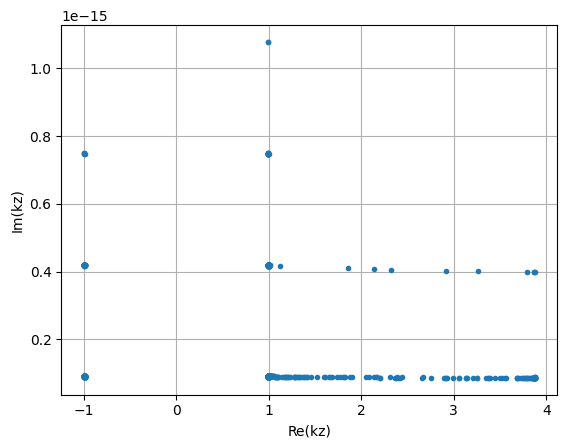

In [11]:
kz_test = solver._kz

kz_fwd = kz_test
kz_bwd = -kz_test

plt.plot(kz_fwd[0,0,0].cpu().real, kz_fwd[1,0,0].cpu().imag, '.')
plt.xlabel('Re(kz)')
plt.ylabel('Im(kz)')
plt.grid()
# plt.ylim([-1, 1])

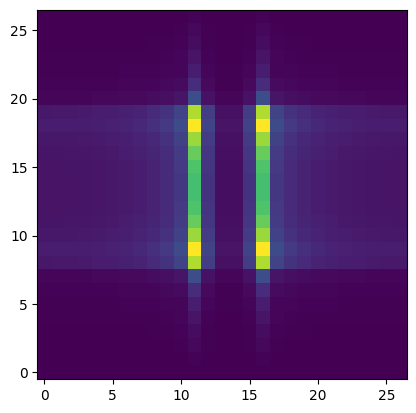

In [97]:
def reconstruct_mode(vn, Gx, Gy, x, y):
    """
    Reconstruct real-space field of a single RCWA mode.
    """
    phase = (
        backend.exp(1j * (Gx[:, None, None] * x[None, :, None]
                        + Gy[:, None, None] * y[None, None, :]))
    )
    field = backend.sum(vn[:, None, None] * phase, dim=0)
    return field

mx = backend.arange(-M, M + 1)
my = backend.arange(-N, N + 1)

Gx = 2 * backend.pi * mx / Lx
Gy = 2 * backend.pi * my / Ly

Gx2, Gy2 = backend.meshgrid(Gx, Gy, indexing="ij")

Gx_flat = Gx2.reshape(-1)
Gy_flat = Gy2.reshape(-1)

x = backend.linspace(0, Lx, Nx)
y = backend.linspace(0, Ly, Ny)

Ex = eigvecs[..., :eigvecs.shape[-2]//2, :]
Ey = eigvecs[..., eigvecs.shape[-2]//2:, :]

mode_ind = 0
Ex_m_ifft = backend.ifft2(Ex[..., :, mode_ind].reshape([Ex.shape[0], Ex.shape[1], Ex.shape[2], 2*M+1, 2*N+1]), dim=(-2, -1))
Ey_m_ifft = backend.ifft2(Ey[..., :, mode_ind].reshape([Ey.shape[0], Ey.shape[1], Ey.shape[2], 2*M+1, 2*N+1]))


Ex_m = reconstruct_mode(Ex[0,0,0, :, mode_ind], Gx_flat, Gy_flat, x, y)
Ey_m = reconstruct_mode(Ey[0,0,0, :, mode_ind], Gx_flat, Gy_flat, x, y)


plt.imshow(Ex_m_ifft[0,0,0].cpu().abs().T, origin='lower')


In [ ]:
plt.imshow(Ex)

tensor([[3.5355e-01, 3.5354e-01, 3.5355e-01,  ..., 9.6892e-13, 1.7939e-13,
         7.0803e-14],
        [6.9203e-09, 1.0368e-03, 6.9745e-05,  ..., 1.5573e-12, 2.2438e-10,
         9.4913e-13],
        [3.6056e-09, 5.3924e-04, 3.6322e-05,  ..., 2.8235e-07, 2.4497e-12,
         3.0323e-09],
        ...,
        [8.1299e-08, 5.3946e-04, 3.6276e-05,  ..., 1.3575e-06, 2.1763e-12,
         1.2379e-10],
        [1.6247e-07, 1.0370e-03, 6.9639e-05,  ..., 1.1054e-12, 1.8936e-10,
         1.3266e-12],
        [3.5356e-01, 3.5355e-01, 3.5355e-01,  ..., 1.1972e-12, 2.6602e-13,
         1.1590e-13]], device='cuda:1', dtype=torch.float64)

In [85]:
Ex = eigvecs[..., :, :eigvecs.shape[-2]//2]
Ey = eigvecs[..., :, eigvecs.shape[-2]//2:]

print(Ex.shape)
print(Ey.shape)

torch.Size([3, 2, 2, 1682, 841])
torch.Size([3, 2, 2, 1682, 841])


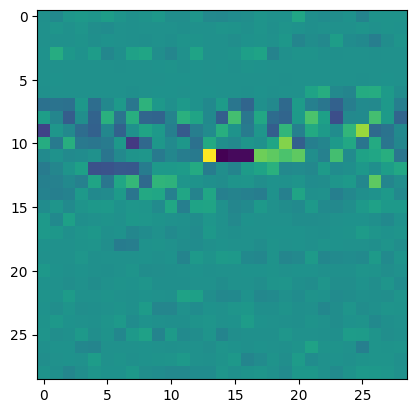

In [86]:
mode_ind = 0
Ex_m = Ex[...,mode_ind,:].reshape([Ex.shape[0], Ex.shape[1], Ex.shape[2], 2*M+1, 2*N+1])
Ey_m = Ey[...,mode_ind,:].reshape([Ey.shape[0], Ey.shape[1], Ey.shape[2], 2*M+1, 2*N+1])

plt.imshow(Ex_m[0,0,0].real.cpu())

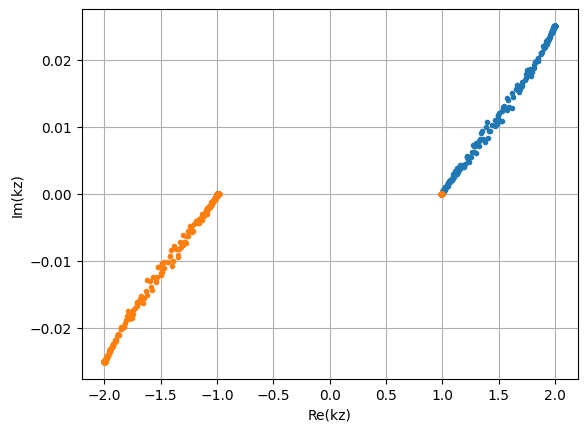

In [37]:
kz = -1j*backend.sqrt(eigvals)
kz_fwd = kz.clone()
mask = backend.imag(kz_fwd) < 0
kz_fwd[mask] = -kz_fwd[mask]
kz_bwd = -kz_fwd

plt.plot(kz_fwd[0,0,0].cpu().real, kz_fwd[0,0,0].cpu().imag, '.')
plt.plot(kz_bwd[0,0,0].cpu().real, kz_bwd[0,0,0].cpu().imag, '.')
plt.xlabel('Re(kz)')
plt.ylabel('Im(kz)')
plt.grid()

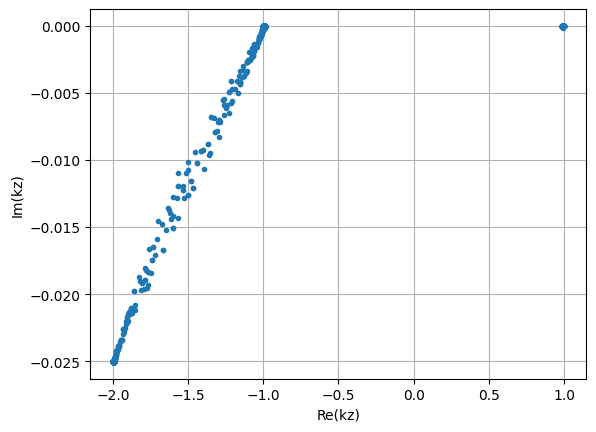

In [29]:
plt.plot(kz[0,0,0].cpu().real, kz[0,0,0].cpu().imag, '.')
plt.xlabel('Re(kz)')
plt.ylabel('Im(kz)')
plt.grid()

torch.Size([3, 2, 2, 1226])

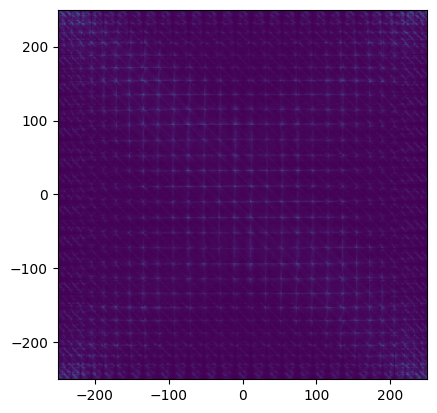

In [45]:
plt.imshow(Omega2[2][0,1,0].cpu().abs(), extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))

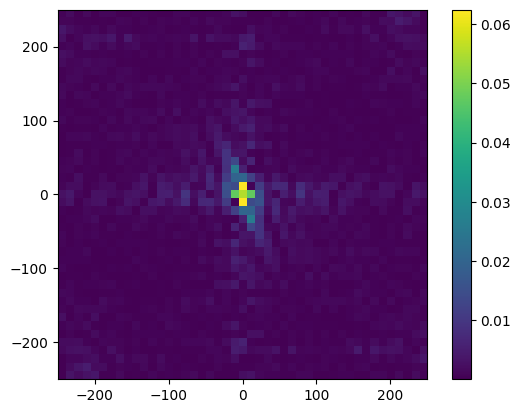

In [4]:
plt.imshow(Pxy[0].cpu().abs().T, origin='lower', extent=(-period[0]/2, period[0]/2, -period[1]/2, period[1]/2))
plt.colorbar()

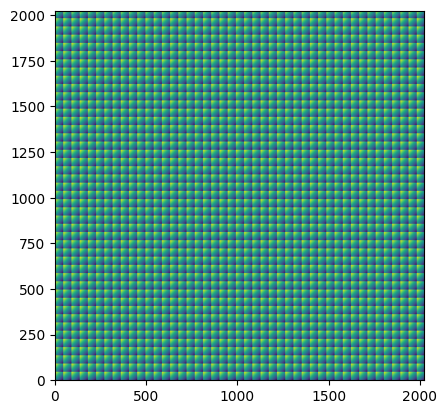

In [5]:
plt.imshow(solver.index_map[1].cpu(), origin='lower')